In [27]:
from jax.random import uniform, normal, PRNGKey
from jax.scipy.stats.norm import cdf as normal_cdf
key = PRNGKey(42)

In [28]:
from qfso.models.statevector import factorized
import matplotlib.pyplot as plt
from jax import numpy as jnp


def random_probability_vector(n) -> jnp.ndarray:
    random_vector = jnp.abs(normal(key, (2**n,)))
    return random_vector / jnp.sum(random_vector)

def discretized_normal_probability(interval: tuple[float, float], num_bins: int, loc: float = 0) -> jnp.ndarray:

    min_val, max_val = interval
    bins = jnp.linspace(min_val, max_val, num_bins + 1)
    probabilities = []
    
    for i in range(num_bins):
        prob = normal_cdf(bins[i+1], loc=loc, scale=1) - normal_cdf(bins[i], loc=loc, scale=1)
        probabilities.append(prob)
        
    probability_vector = jnp.array(probabilities)
    probability_vector /= jnp.sum(probability_vector) #normalize
    return probability_vector


def plot_distributions(distributions: jnp.ndarray, title: str):
    if type(distributions) is not list:
        distributions = [distributions]
    for distribution in distributions:
        plt.bar(range(len(distribution)), distribution, alpha=0.5)
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.show()

def uniform_like(p):
    return jnp.ones_like(p) / p.size

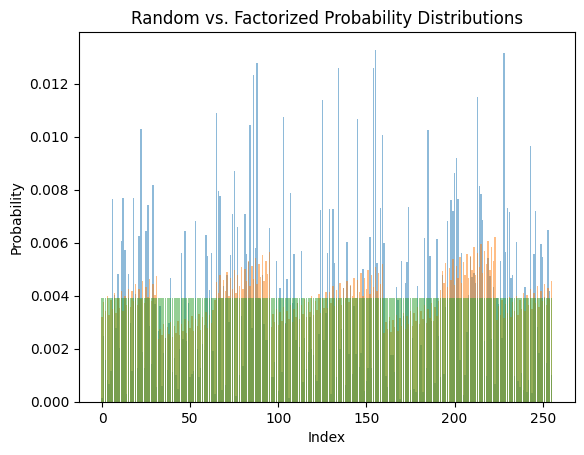

In [29]:
n=8
p = random_probability_vector(n)
#p = discretized_normal_probability((-2, 3), 2**n, loc=0)
q = factorized.match_first_order(p)
u = uniform_like(p)
plot_distributions([p, q, u], "Random vs. Factorized Probability Distributions")

In [30]:
from qfso.models.statevector import metrics
sigma = n
print(metrics.mmd_qubits(p,q, sigma))
print(metrics.mmd_qubits(p,u, sigma))

0.00078920025
0.0028995045


In [31]:
from qfso.models.statevector import metrics

alpha = 2
print(metrics.renyi_entropy(p, alpha=alpha)/jnp.log(2))
print(metrics.renyi_entropy(q, alpha=alpha)/jnp.log(2))
print(metrics.renyi_entropy(u, alpha=alpha)/jnp.log(2))
print(metrics.renyi_entropy(p, alpha=1))

7.3232574
7.9363875
8.0
5.2487087


In [32]:
import jax
import jax.numpy as jnp
from scipy.optimize import brentq
from qfso.models.statevector.metrics import renyi_entropy

def generate_distribution_with_target_entropy(n_states: int, target_entropy: float, key: jax.Array, alpha: float = 1) -> jnp.ndarray:
    """Generates a discrete probability distribution with a specific target Renyi entropy. 
    For alpha=1, this corresponds to the Shannon entropy.

    This function uses a Boltzmann distribution (softmax) over a random energy landscape.
    It solves for the inverse temperature beta such that the resulting distribution 
    matches the requested entropy. This is useful for benchmarking IQP-based 
    generative models under different data complexity regimes.

    Args:
        n_states (int): The number of possible outcomes (size of the Hilbert space 
            or bitstring space).
        target_entropy (float): Desired Renyi entropy in nats. Must be in the 
            range [0, log(n_states)].
        alpha (float): The order of the Renyi entropy. Default is 1 (Shannon entropy).
        key (jax.Array): A JAX PRNG key used to generate the underlying 
            random energy landscape.

    Returns:
        jnp.ndarray: A 1D array of shape (n_states,) representing the 
            normalized probability distribution.

    Raises:
        ValueError: If target_entropy is greater than the maximum possible 
            entropy for the given n_states.

    Notes:
        The implementation uses Brent's root-finding method to find the optimal 
        inverse temperature. For target_entropy = log(n_states), a uniform 
        distribution is returned directly.
    """
    max_entropy = float(jnp.log(n_states))
    if target_entropy >= max_entropy:
        return jnp.ones(n_states) / n_states
    elif target_entropy <= 0.0:
        dist = jnp.zeros(n_states)
        # Se entropia 0, collassiamo tutto su un singolo stato a caso
        idx = jax.random.randint(key, shape=(), minval=0, maxval=n_states)
        return dist.at[idx].set(1.0)
    
    # Generiamo un panorama di "energie" casuali
    energies = jax.random.normal(key, (n_states,))
    
    # Shift delle energie per stabilità numerica (log-sum-exp trick)
    shifted_energies = energies - jnp.min(energies)
    
    # Funzione per la distribuzione di Boltzmann
    def boltzmann_dist(beta: float) -> jnp.ndarray:
        exp_terms = jnp.exp(-beta * shifted_energies)
        return exp_terms / jnp.sum(exp_terms)
    
    # Funzione obiettivo per il root-finding: S(beta) - target = 0
    def entropy_diff(beta: float) -> float:
        p = boltzmann_dist(beta)
        # Mask per evitare warning su log(0) se beta è molto grande
        p_safe = jnp.where(p > 0, p, 1e-12)
        current_entropy = renyi_entropy(p_safe, alpha=alpha)
        return float(current_entropy - target_entropy)
    
    # Ricerca dello zero: S(beta) decresce da max_entropy (a beta=0) a 0 (a beta=inf)
    # Cerchiamo il beta ottimale nell'intervallo [0, 1000]
    try:
        beta_opt = brentq(entropy_diff, 0.0, 1000.0)
    except ValueError:
        # Se 1000 non basta per raggiungere energie abbastanza fredde, allarghiamo il bound
        beta_opt = brentq(entropy_diff, 0.0, 100000.0)
        
    return boltzmann_dist(beta_opt)

In [33]:
H_max = float(jnp.log(2**n))
H_target = H_max - 0.1

p_h = generate_distribution_with_target_entropy(n_states=2**n, target_entropy=H_target, key=key, alpha=alpha)
q_h = factorized.match_first_order(p_h)
u_h = uniform_like(p_h)

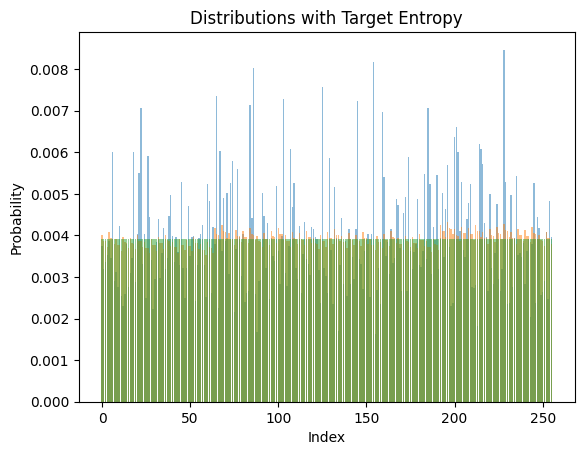

In [34]:
plot_distributions([p_h, q_h, u_h], "Distributions with Target Entropy")

In [35]:
print(metrics.renyi_entropy(p_h, alpha=alpha))
print(metrics.renyi_entropy(q_h, alpha=alpha))
print(metrics.renyi_entropy(u_h, alpha=alpha))

5.4451776
5.543659
5.5451775


In [36]:
print(metrics.mmd_qubits(p_h, q_h, sigma))
print(metrics.mmd_qubits(p_h, u_h, sigma))

0.00024412503
0.00028070452


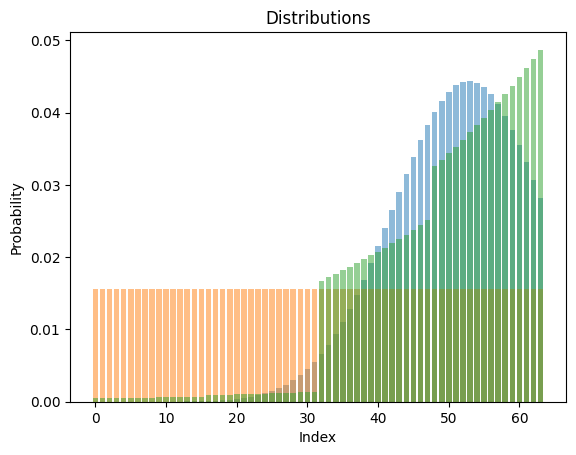

In [114]:
n = 6
p = discretized_normal_probability((-5, 1), 2**n, loc=0)
#p = random_probability_vector(n)
u = uniform_like(p)
f = factorized.match_first_order(p)
plot_distributions([p,u,f], "Distributions")   

In [117]:
from jax.scipy.linalg import hadamard
from itertools import combinations

def wht(p):
    H = hadamard(p.size)
    return  H @ p

def sorted_mmd_contributions(p, q, sigma):
    
    ph = wht(p)
    qh = wht(q)
    delta = ph - qh

    n = int(jnp.log2(p.size))
    r = 0.5*(1-jnp.exp(-1/(sigma*2)))
    print(r)
    
    mean = n*r
    var = n*r*(1-r)
    lowest_k = max(int(jnp.floor(mean - 3*jnp.sqrt(var)).item()), 1)
    highest_k = min(int(jnp.ceil(mean + 3*jnp.sqrt(var)).item()), n)
    values = []
    print(lowest_k,highest_k)
    for k in range(lowest_k, highest_k+1):
        rk = r**k * (1-r)**(n-k)
        for bits in combinations(range(n), k):
            idx = 0
            for bit in bits: idx += 1 << bit
            values.append((idx, rk*delta[idx]**2, delta[idx]))
    return sorted(values, key=lambda x: x[1], reverse=True) 

In [118]:
sigma = 0.1*n
sorted_contributions = sorted_mmd_contributions(p, u, sigma=sigma)
for bit,mmd_elem,delta_elem in sorted_contributions:
    print(f"Index: {bit}\t ({bit:06b}), Contribution: {mmd_elem:1.4e} (Delta: {delta_elem:1.4f})\t Ignore from now, get mmd^2 < {2*mmd_elem*2**n:1.4e}")

0.2827009
1 6
Index: 32	 (100000), Contribution: 4.8033e-02 (Delta: -0.9459)	 Ignore from now, get mmd^2 < 6.1482e+00
Index: 16	 (010000), Contribution: 5.5001e-03 (Delta: -0.3201)	 Ignore from now, get mmd^2 < 7.0401e-01
Index: 48	 (110000), Contribution: 1.5096e-03 (Delta: 0.2671)	 Ignore from now, get mmd^2 < 1.9322e-01
Index: 24	 (011000), Contribution: 6.7885e-04 (Delta: -0.1791)	 Ignore from now, get mmd^2 < 8.6893e-02
Index: 8	 (001000), Contribution: 6.1009e-04 (Delta: -0.1066)	 Ignore from now, get mmd^2 < 7.8091e-02
Index: 56	 (111000), Contribution: 4.0025e-04 (Delta: 0.2191)	 Ignore from now, get mmd^2 < 5.1232e-02
Index: 4	 (000100), Contribution: 1.5598e-04 (Delta: -0.0539)	 Ignore from now, get mmd^2 < 1.9966e-02
Index: 20	 (010100), Contribution: 1.4081e-04 (Delta: -0.0816)	 Ignore from now, get mmd^2 < 1.8023e-02
Index: 40	 (101000), Contribution: 9.1148e-05 (Delta: 0.0656)	 Ignore from now, get mmd^2 < 1.1667e-02
Index: 52	 (110100), Contribution: 9.0352e-05 (Delta: 0

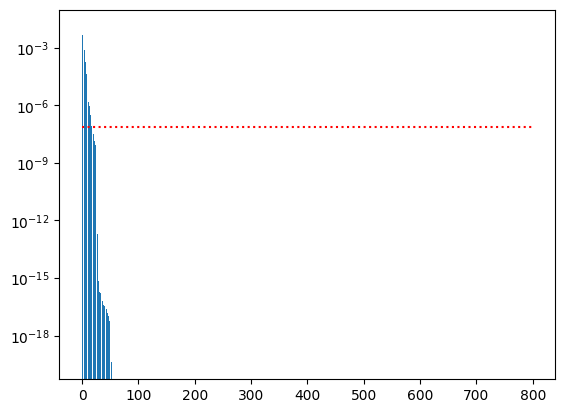

In [86]:
plt.yscale('log')
plt.bar(range(len(sorted_contributions)), [elem[1] for elem in sorted_contributions])
plt.hlines(y=1e-5/(2**(n+1)), xmin=0, xmax=800, colors="red", linestyles="dotted")


<BarContainer object of 6 artists>

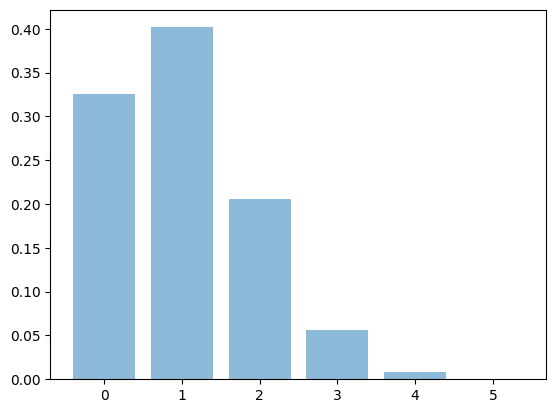

In [87]:
from scipy.special import comb
plt.bar(range(n), [(0.5)**n*comb(n, k)*(1-jnp.exp(-1/(2*sigma)))**k*(1+jnp.exp(-1/(2*sigma)))**(n-k) for k in range(n)], alpha=0.5, label="Binomial Coefficients")

In [88]:
from copy import copy
def gf2_rank_bitwise(rows: list[int], n: int) -> int:
    """
    Computes the rank of a matrix over GF(2) using row reduction.
    Assumes binary values (0 or 1).
    """
    m = len(rows)
    
    # 1. Gaussian Elimination
    rank = 0
    row_idx = 0
    for col in range(n - 1, -1, -1):
        # Find pivot
        pivot_idx = row_idx
        while pivot_idx < m and not (rows[pivot_idx] & (1 << col)):
            pivot_idx += 1
            
        if pivot_idx == m:
            continue # No pivot found, move to next column
            
        # Swap rows
        rows[row_idx], rows[pivot_idx] = rows[pivot_idx], rows[row_idx]
        
        # Eliminate other rows
        for i in range(m):
            if i != row_idx and (rows[i] & (1 << col)):
                rows[i] ^= rows[row_idx]
                
        rank += 1
        row_idx += 1
        
    return rank

def biggest_independent_set(contributions, n):
    independent_set = []
    for idx, *_ in contributions:
        if gf2_rank_bitwise(copy(independent_set) + [idx], n) == len(independent_set)+1:
            independent_set.append(idx)
        if len(independent_set) >= n:
            break

    return independent_set


In [89]:
bis = biggest_independent_set(sorted_contributions, n)
bis

[48, 40, 36, 34, 33, 4]

In [90]:
bis

[48, 40, 36, 34, 33, 4]

In [91]:
def gf2_inverse(rows:list, n:int):
    m = len(rows)
    # Create an identity matrix of the same size
    identity = [1 << i for i in range(n)]
    rows = copy(rows)
    # Perform Gaussian elimination to find the inverse
    for col in range(n - 1, -1, -1):
        pivot_idx = None
        for row_idx in range(m):
            if rows[row_idx] & (1 << col):
                pivot_idx = row_idx
                break
        
        if pivot_idx is None:
            raise ValueError("Matrix is singular and cannot be inverted.")
        
        # Swap the pivot row with the current row
        rows[pivot_idx], rows[col] = rows[col], rows[pivot_idx]
        identity[pivot_idx], identity[col] = identity[col], identity[pivot_idx]
        
        # Eliminate other rows
        for row_idx in range(m):
            if row_idx != col and (rows[row_idx] & (1 << col)):
                rows[row_idx] ^= rows[col]
                identity[row_idx] ^= identity[col]
    
    return identity

In [92]:
bis_inv = gf2_inverse(bis, n)
bis_inv

[52, 44, 32, 38, 37, 36]

In [93]:
def apply_matrix(mat, vec):
    result = 0
    for i in range(len(mat)):
        if vec & (1 << i):
            result ^= mat[i]
    return result

def biggest_independent_fourier(bis, contributions):
    bifc = {}
    for idx, _, delta in contributions:
        if idx in bis:
            bifc[idx] = delta.item()
    return bifc

In [94]:
bifc = biggest_independent_fourier(bis, sorted_contributions)

In [104]:
def sample(bis, bis_inv, bifc, num_samples):
    random = uniform(key=key, shape=(num_samples, len(bis)))
    sample_vec = 0
    samples = []
    for r in random:
        sample_vec = 0
        for i,k in enumerate(bis):
            pk = 0.5*(1-bifc[k])
            if r[i] < pk:
                sample_vec ^= 1 << i
        samples.append(apply_matrix(bis_inv, sample_vec))
    return samples

def match_biggest_contributions(bis, bis_inv, bifc):

    n = len(bis)
    marginals = [(0.5*(1+bifc[k]), 0.5*(1-bifc[k])) for k in bis]
   
    product_dist = jnp.array([jnp.prod(
        jnp.array([marginals[bit][(i >> (bit)) & 1] for bit in range(n)])
        ) for i in range(2**n)])
   
    dist = 2**n*[0]
    for i,p in enumerate(product_dist):
        new_idx = apply_matrix(bis_inv, i)
        dist[new_idx] = p
    return jnp.array(dist)
    

In [105]:
u = factorized.match_first_order(p)
u_new = match_biggest_contributions(bis, bis_inv, bifc)

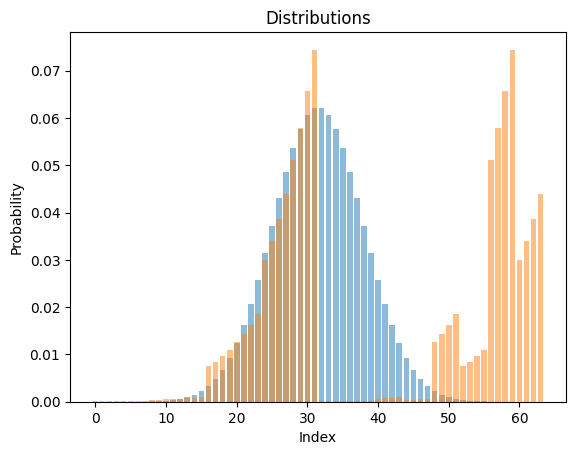

In [106]:
plot_distributions([p, u_new], "Distributions")   

In [98]:
for k,v in bifc.items():
    print(f"({k}) {k:010b} -> {v}")

(48) 0000110000 -> -0.9751625061035156
(40) 0000101000 -> -0.6018867492675781
(36) 0000100100 -> -0.25868433713912964
(34) 0000100010 -> -0.1257150024175644
(33) 0000100001 -> -0.06246241554617882
(4) 0000000100 -> 1.043081283569336e-07


In [99]:
wht(u_new)

Array([ 1.0000000e+00, -6.2462404e-02, -1.2571496e-01,  7.8524202e-03,
        0.0000000e+00,  0.0000000e+00, -2.9802322e-08,  8.9406967e-08,
       -6.0188675e-01,  3.7595294e-02,  7.5666159e-02, -4.7262982e-03,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.1920929e-07,
       -9.7516263e-01,  6.0911030e-02,  1.2259260e-01, -7.6574385e-03,
       -1.4901161e-08,  1.4901161e-08,  0.0000000e+00, -5.9604645e-08,
        5.8693743e-01, -3.6661528e-02, -7.3786855e-02,  4.6089068e-03,
        1.4901161e-08, -1.4901161e-08,  0.0000000e+00,  1.1920929e-07,
        3.7252903e-09,  0.0000000e+00, -3.7252903e-09, -2.9802322e-08,
       -2.5868440e-01,  1.6158044e-02,  3.2520518e-02, -2.0312965e-03,
        0.0000000e+00, -3.7252903e-09,  7.4505806e-09,  4.0978193e-08,
        1.5569870e-01, -9.7253025e-03, -1.9573674e-02,  1.2226030e-03,
        3.7252903e-09,  0.0000000e+00, -3.7252903e-09,  1.4901161e-08,
        2.5225931e-01, -1.5756700e-02, -3.1712785e-02,  1.9808672e-03,
      

In [100]:
print(metrics.mmd_qubits(p,u, sigma))
print(metrics.mmd_qubits(p,u_new, sigma))

0.08364117
0.118141524


In [52]:
new_samples=sample(bis, bis_inv, bifc, 10_000)

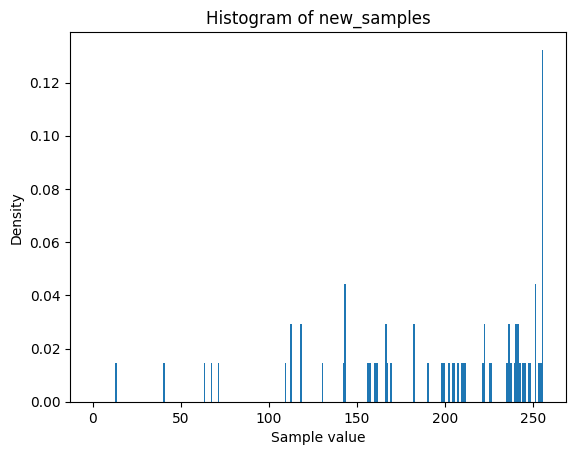

In [53]:
plt.hist(new_samples, bins=range(257), density=True)
plt.title("Histogram of new_samples")
plt.xlabel("Sample value")
plt.ylabel("Density")
plt.show()